In [10]:
class manbot():
    def __init__(self, name, coop_stat):
        self.name = name
        self.coop_stat = coop_stat

    def __repr__(self):
        return f"manbot(name={self.name}, coop_stat={self.coop_stat})"

In [11]:
class node():
    def __init__(self, xpos, ypos):

        self.xpos = xpos
        self.ypos = ypos

    def __repr__(self):
        return f"node(xpos={self.xpos}, ypos={self.ypos})"

In [12]:
import random
class mapper():
    def __init__(self):

        repete = int(input("Number of population nodes: "))
        grid = int(input("Grid size"))

        self.node_dic = {}

        i = 0
        while i < repete: 

            

            xx = random.uniform(0, grid)
            yy = random.uniform(0, grid)


            new = node(xx,yy)

            self.node_dic.update({new: {'connections': [], 'attributes': [], "inhabitants": []}})

            i += 1


            
        

In [13]:
import networkx as nx


class connector():
    def __init__(self, node_dic):

        self.nodes = node_dic

        
       #Create connections based on distance

     
        length_list = []

        for noodle in self.nodes:
            temp_list = []
            for noodle2 in self.nodes:
                dist = ((noodle.xpos-noodle2.xpos)**2 + (noodle.ypos - noodle2.ypos)**2)**.5
                if dist != 0:
                    temp_list.append(dist)

            minn = min(temp_list)
            length_list.append(minn)

        length_s = len(length_list)
        summ = 0
    
        for numb in length_list:

            summ += numb

        av = summ/length_s
        
        print(av)
        
        
        #Ensure no isolated nodes

        for node1 in self.nodes:

            if len(self.nodes[node1]['connections']) == 0:

                closest_node = None
                closest_dist = float('inf')

                for node2 in self.nodes:

                    if node1 != node2:

                        dist = (
                            ((node1.xpos - node2.xpos) ** 2) +
                            ((node1.ypos - node2.ypos) ** 2)
                        ) ** 0.5

                        if dist < closest_dist:
                            closest_dist = dist
                            closest_node = node2

                self.nodes[node1]['connections'].append(closest_node)

        #Build network

        G = nx.Graph()

        for node in self.nodes:
            G.add_node(node)

        for node in self.nodes:
            for neighbor in self.nodes[node]['connections']:
                G.add_edge(node, neighbor)

       #Force graph to not be connected

         # ============================================
        # FORCE GRAPH TO BE CONNECTED
        # ============================================

        while not nx.is_connected(G):

            components = list(nx.connected_components(G))

            best_pair = None
            best_dist = float('inf')

            # Compare EVERY pair of components
            for i in range(len(components)):
                for j in range(i + 1, len(components)):

                    comp1 = components[i]
                    comp2 = components[j]

                    # Find closest nodes between these components
                    for node1 in comp1:
                        for node2 in comp2:

                            dist = (
                                ((node1.xpos - node2.xpos) ** 2) +
                                ((node1.ypos - node2.ypos) ** 2)
                            ) ** 0.5

                            if dist < best_dist:
                                best_dist = dist
                                best_pair = (node1, node2)

            # Add shortest possible bridge
            node1, node2 = best_pair

            self.nodes[node1]['connections'].append(node2)
            self.nodes[node2]['connections'].append(node1)

            G.add_edge(node1, node2)

In [14]:
import random

class populator():
    def __init__(self, nodee_dic):

        self.nodd = nodee_dic
    
        chance = [1,2,3]

        name_count = 1

        for nodd in self.nodd:
            i = 0 
            temp_bot_list = []
            while i < 5:
                clonename = ('Bot'+ str(name_count))
                bot_name = clonename
                coop_stat = random.choice(chance)
                clonename = manbot(bot_name, coop_stat)
    
                temp_bot_list.append(clonename)

                name_count += 1

                i += 1
    
            nodee_dic[nodd]['inhabitants'].append(temp_bot_list)
    




        

    

In [15]:
%matplotlib widget

import networkx as nx
import matplotlib.pyplot as plt
import mplcursors

class grapher():
    def __init__(self, map_dic):

        self.map_map = map_dic
    
        plt.clf()
        
        g = nx.Graph()
        pos = {}
        
        for start in self.map_map:
            g.add_node(start)
            pos.update({start: (start.xpos, start.ypos)})
            for connect in self.map_map[start]['connections']:
                g.add_edge(start, connect)
        
        nx.draw_networkx_edges(g, pos, edge_color = 'green')
        
        node_collection = nx.draw_networkx_nodes(g, pos, node_color = 'skyblue', node_size = 100)
        
        cursor = mplcursors.cursor(node_collection, hover=True)
        
        @cursor.connect("add")
        def on_add(sel):
            node_index = sel.index
        
            node_instance = list(g.nodes)[node_index]
            node_data = self.map_map[node_instance]
        
            display_text = (f"Inhabitants; {len(node_data['inhabitants'][0])}\n")
        
            sel.annotation.set_text(display_text)
            sel.annotation.get_bbox_patch().set(fc = 'white', alpha = 0.9)
        
        plt.show()

Number of population nodes:  200
Grid size 20


0.747262220409932


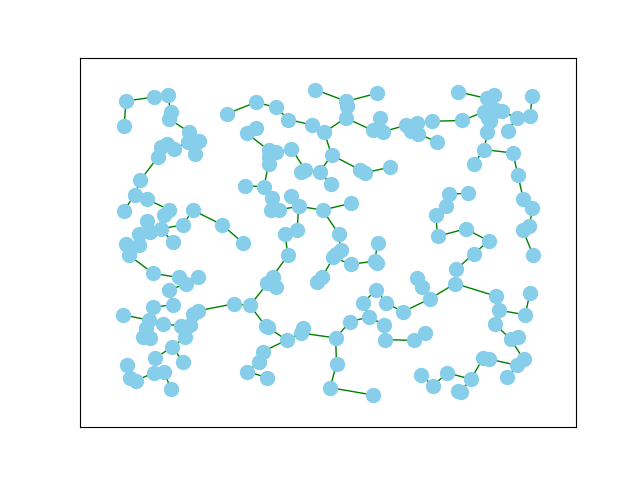

In [17]:
my_mapper = mapper()
my_connector = connector(my_mapper.node_dic)
my_populator = populator(my_mapper.node_dic)

my_grapher = grapher(my_mapper.node_dic)